# Tutorial 2 — Analysis

Companion notebook to [Tutorial Part 2](../tutorial.rst). It loads the three solved `tutorial_02` scenarios, inspects the extracted consumer values, compares food-group consumption and the objective breakdown across scenarios, and finally compares total GHG emissions against the fixed-diet run from Tutorial 1.

Prerequisites: both tutorial workflows must have been solved locally.

```bash
tools/smk -j4 --configfile config/tutorial/01_ghg_prices.yaml
tools/smk -j4 --configfile config/tutorial/02_consumer_values.yaml
```

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

project_root = Path("..", "..").resolve()
scenarios = ["baseline", "ghg_mid", "ghg_high"]


def load_analysis(config_name: str, filename: str) -> pd.DataFrame:
    """Concatenate a per-scenario parquet file for a given tutorial config."""
    results = project_root / "results" / config_name / "analysis"
    return pd.concat(
        pd.read_parquet(results / f"scen-{s}" / filename).assign(
            scenario=s, config=config_name
        )
        for s in scenarios
    )

## Inspect the extracted consumer values

The `baseline` solve fixes consumption at observed 2020 levels; the dual variables of the binding per-(food, country) equality constraints on the `food_consumption` links are the consumer values. Each value is expressed in bn USD per Mt of that food in that country — the marginal utility the non-baseline scenarios use when letting diet shift.

In [2]:
values = pd.read_csv(
    project_root / "results/tutorial_02/consumer_values/baseline/values.csv"
)

# Top 10 (food, country) pairs by absolute consumer value.
top = (
    values.reindex(
        values["value_bnusd_per_mt"].abs().sort_values(ascending=False).index
    )
    .head(10)[["food", "food_group", "country", "value_bnusd_per_mt"]]
    .reset_index(drop=True)
)
top

,food,food_group,country,value_bnusd_per_mt
0,cottonseed-oil,oil,ERI,-49.999989
1,cottonseed-oil,oil,SSD,-49.999989
2,cottonseed-oil,oil,TZA,-49.999989
3,cottonseed-oil,oil,ETH,-49.980656
4,cottonseed-oil,oil,DJI,-49.971268
5,cottonseed-oil,oil,UGA,-49.969624
6,cottonseed-oil,oil,KEN,-49.968948
7,cottonseed-oil,oil,SOM,-49.968010
8,cottonseed-oil,oil,ZWE,-49.964008
9,cottonseed-oil,oil,SDN,-49.963116


## Does the diet actually move?

Tutorial 1 held consumption fixed; Tutorial 2 lets it respond. The stacked bars below show global food-group consumption (Mt) for each scenario — we expect animal-product categories to contract and plant-based categories to expand as the GHG price rises.

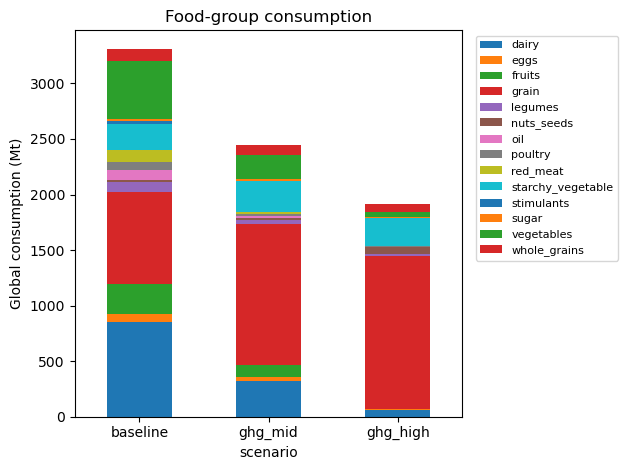

In [3]:
consumption = load_analysis("tutorial_02", "food_group_consumption.parquet")
by_group = (
    consumption.groupby(["scenario", "food_group"])["consumption_mt"]
    .sum()
    .unstack("food_group")
    .reindex(scenarios)
)

ax = by_group.plot.bar(stacked=True, ylabel="Global consumption (Mt)", rot=0)
ax.set_title("Food-group consumption")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()

## Objective breakdown with the utility term visible

The `consumer_values` column represents utility gained from (or disutility of deviating from) baseline consumption, entering the minimisation as a subtraction. It is negative when the flexible diet still sits close enough to baseline that the piecewise utility is net positive; it can turn positive at high GHG prices, when the optimiser pushes consumption far enough away from baseline that the cumulative utility loss exceeds the gain. Meanwhile `ghg_cost` is negative because the model achieves net-negative emissions at these prices — the gap between `ghg_cost` columns in Tutorial 1 vs Tutorial 2 measures how much extra mitigation the flexible diet unlocks.

In [4]:
breakdown = (
    load_analysis("tutorial_02", "objective_breakdown.parquet")
    .set_index("scenario")
    .reindex(scenarios)
)
columns = ["ghg_cost", "consumer_values", "crop_production", "animal_production"]
breakdown[columns].round(2)

category,ghg_cost,consumer_values,crop_production,animal_production
scenario,,,,
baseline,NaN,NaN,50.98,51.92
ghg_mid,-607.79,-20.33,22.68,19.11
ghg_high,-2675.58,92.61,20.36,4.54


## Fixed-diet vs flexible-diet at the same GHG price

Tutorial 1 and Tutorial 2 share the same GHG prices but differ in whether diet is allowed to respond. The gap between the two bars at each GHG price is a rough measure of the additional, demand-side abatement available when consumption is free to move.

scenario     baseline  ghg_mid  ghg_high
config                                  
tutorial_01   -3435.1  -8357.7   -9766.1
tutorial_02   -3435.1 -12155.9  -13377.9


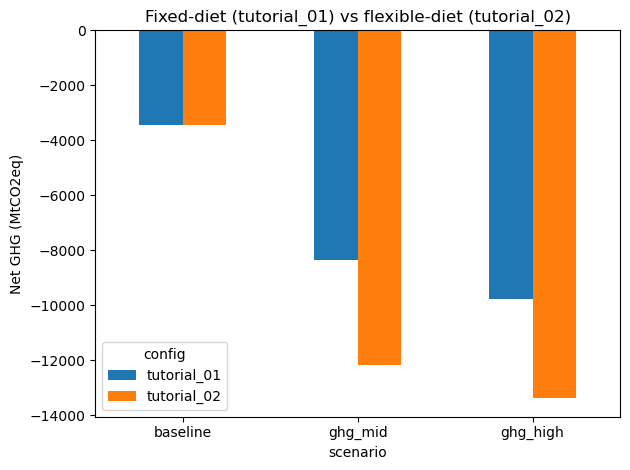

In [5]:
emissions = pd.concat(
    [
        load_analysis("tutorial_01", "net_emissions.parquet"),
        load_analysis("tutorial_02", "net_emissions.parquet"),
    ]
)
totals = (
    emissions.groupby(["config", "scenario"])["mtco2eq"]
    .sum()
    .unstack("scenario")
    .reindex(columns=scenarios)
)
print(totals.round(1))

ax = totals.T.plot.bar(ylabel="Net GHG (MtCO2eq)", rot=0)
ax.set_title("Fixed-diet (tutorial_01) vs flexible-diet (tutorial_02)")
plt.tight_layout()